# 商店房数据分析

# 商店房和高级战斗数据基本一致

挑选一次战斗，统计相同策略组下，商店房和高级战斗房的数据，概率差别不大。

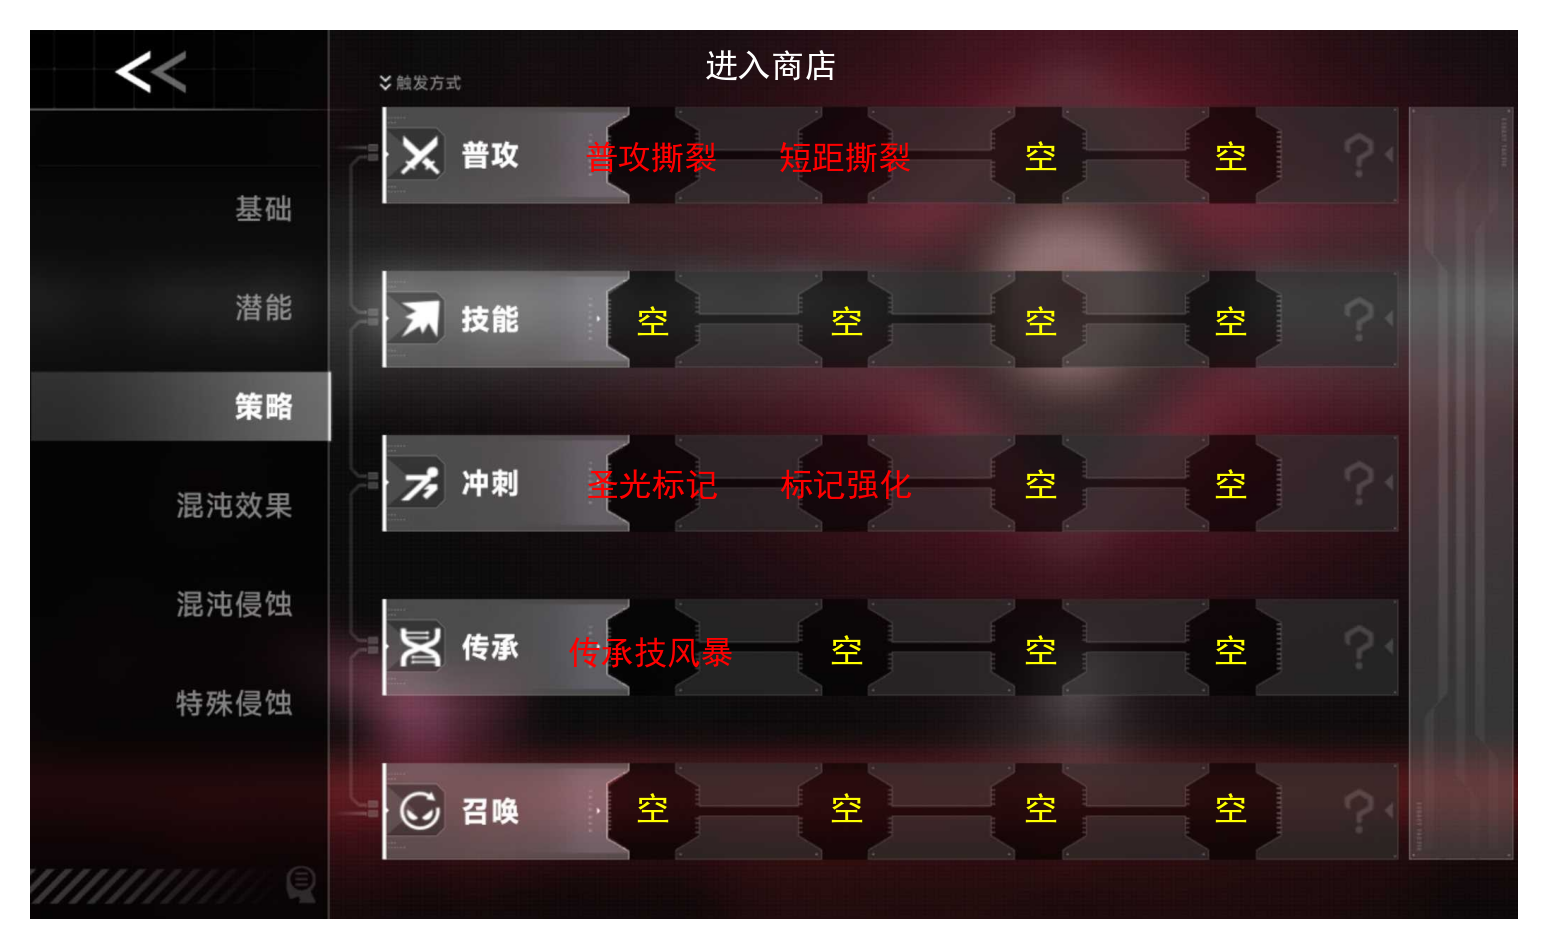

统计撕裂二阶强化出现的概率
0.03648175912043978 VS 0.044061302681992334
统计各个技能位基础策略出现的概率
0.3328335832083958 VS 0.32375478927203066
统计标记二阶强化出现的概率
0.033483258370814596 VS 0.038314176245210725
统计风暴一阶强化出现的概率
0.2818590704647676 VS 0.25862068965517243
统计各个召唤位基础策略出现的概率
0.26486756621689156 VS 0.2739463601532567


In [1]:
from itertools import chain

import utils

cur1, s1 = utils.parse_file("data/商店房/商店夹杂测试.txt")
cur2, s2 = utils.parse_file("data/商店房/高级战斗夹杂测试.txt")
assert cur1 == cur2

utils.draw_status("进入商店", cur1)

s1 = list(chain(*s1))
s2 = list(chain(*s2))

print("统计撕裂二阶强化出现的概率")
print(len(list(x for x in s1 if x.name == '致命撕裂')) / len(s1),
      "VS",
      len(list(x for x in s2 if x.name == '致命撕裂')) / len(s2))
print("统计各个技能位基础策略出现的概率")
print(len(list(x for x in s1 if x.location == '技能')) / len(s1),
      "VS",
      len(list(x for x in s2 if x.location == '技能')) / len(s2))
print("统计标记二阶强化出现的概率")
print(len(list(x for x in s1 if x.name == '标记共鸣')) / len(s1),
      "VS",
      len(list(x for x in s2 if x.name == '标记共鸣')) / len(s2))
print("统计风暴一阶强化出现的概率")
print(len(list(x for x in s1 if x.subclass == '刀刃风暴')) / len(s1),
      "VS",
      len(list(x for x in s2 if x.subclass == '刀刃风暴')) / len(s2))
print("统计各个召唤位基础策略出现的概率")
print(len(list(x for x in s1 if x.location == '召唤')) / len(s1),
      "VS",
      len(list(x for x in s2 if x.location == '召唤')) / len(s2))

# 带满基础策略，进入商店房

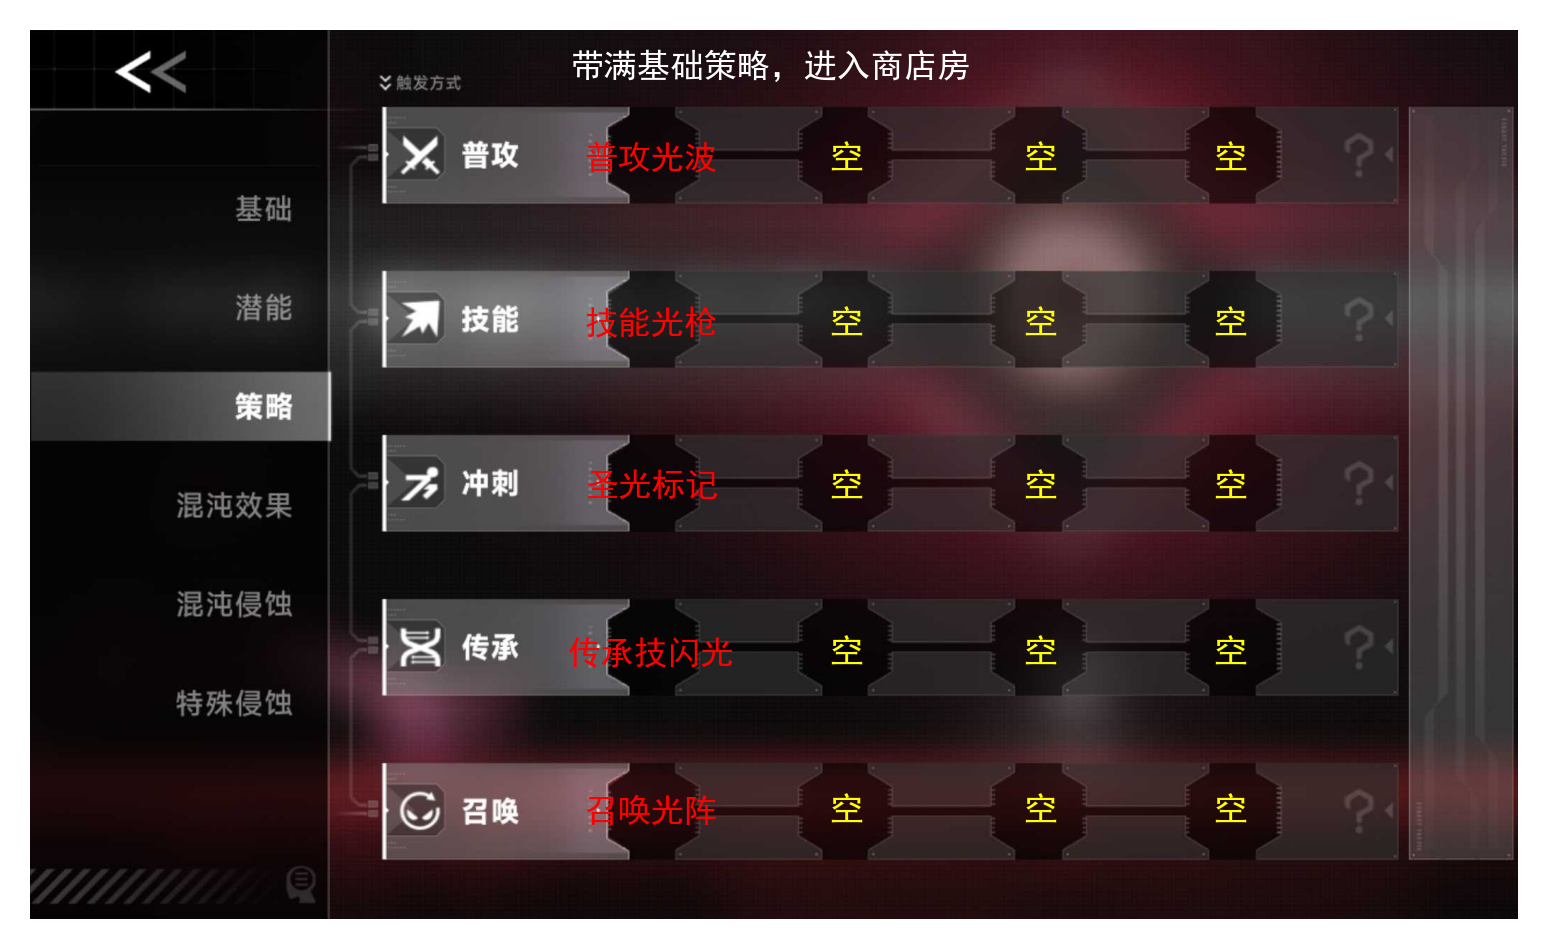

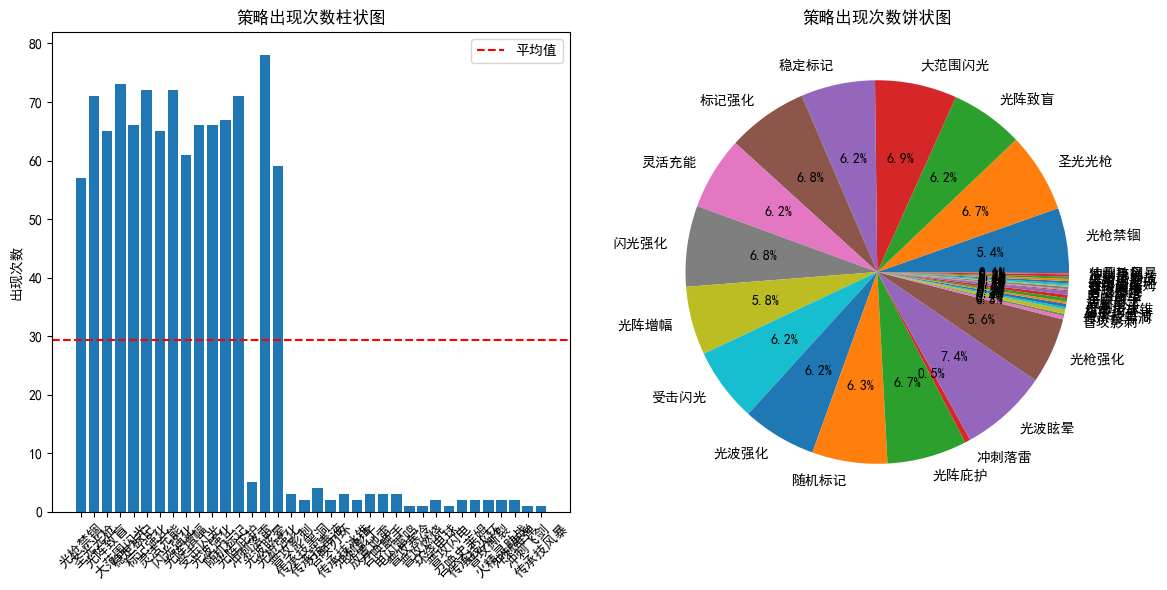

卡方统计量: 1277.4545454545457, p 值: 9.346992754941902e-246
数据不太可能来自均匀分布或离散型概率分布。


In [2]:
from collections import Counter

current_strategies, strategies = utils.parse_file("data/商店房/商店_5个一阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带满基础策略，进入商店房', current_strategies)
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

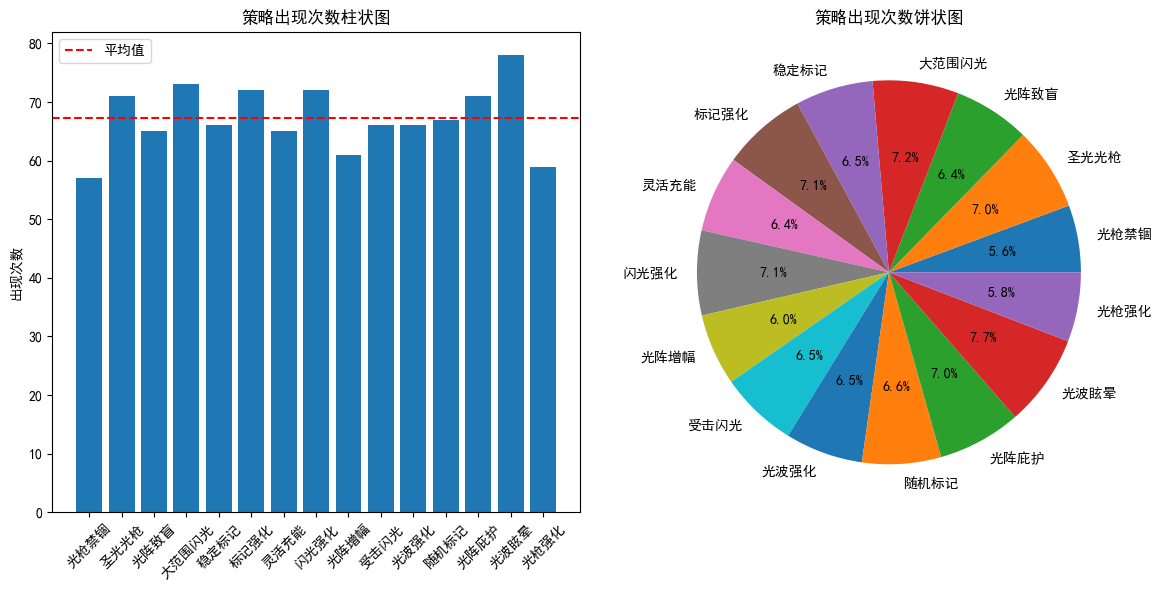

剔除替换策略或升级策略
卡方统计量: 6.673934588701686, p 值: 0.9465516393743804
数据可能来自均匀分布或离散型概率分布


In [3]:
current_strategies = list(chain(*current_strategies))
names = [x.name for x in strategies if x.level != 0]
utils.plot_element_count(names)
print("剔除替换策略或升级策略")
chi2, p = utils.test_uniform_distribution(list(Counter(names).values()))

# 当前猜想：所有一阶强化概率相同，有较小的概率出现替换或升级

# 扩展场景：一阶强化和二阶强化概率是否相等。

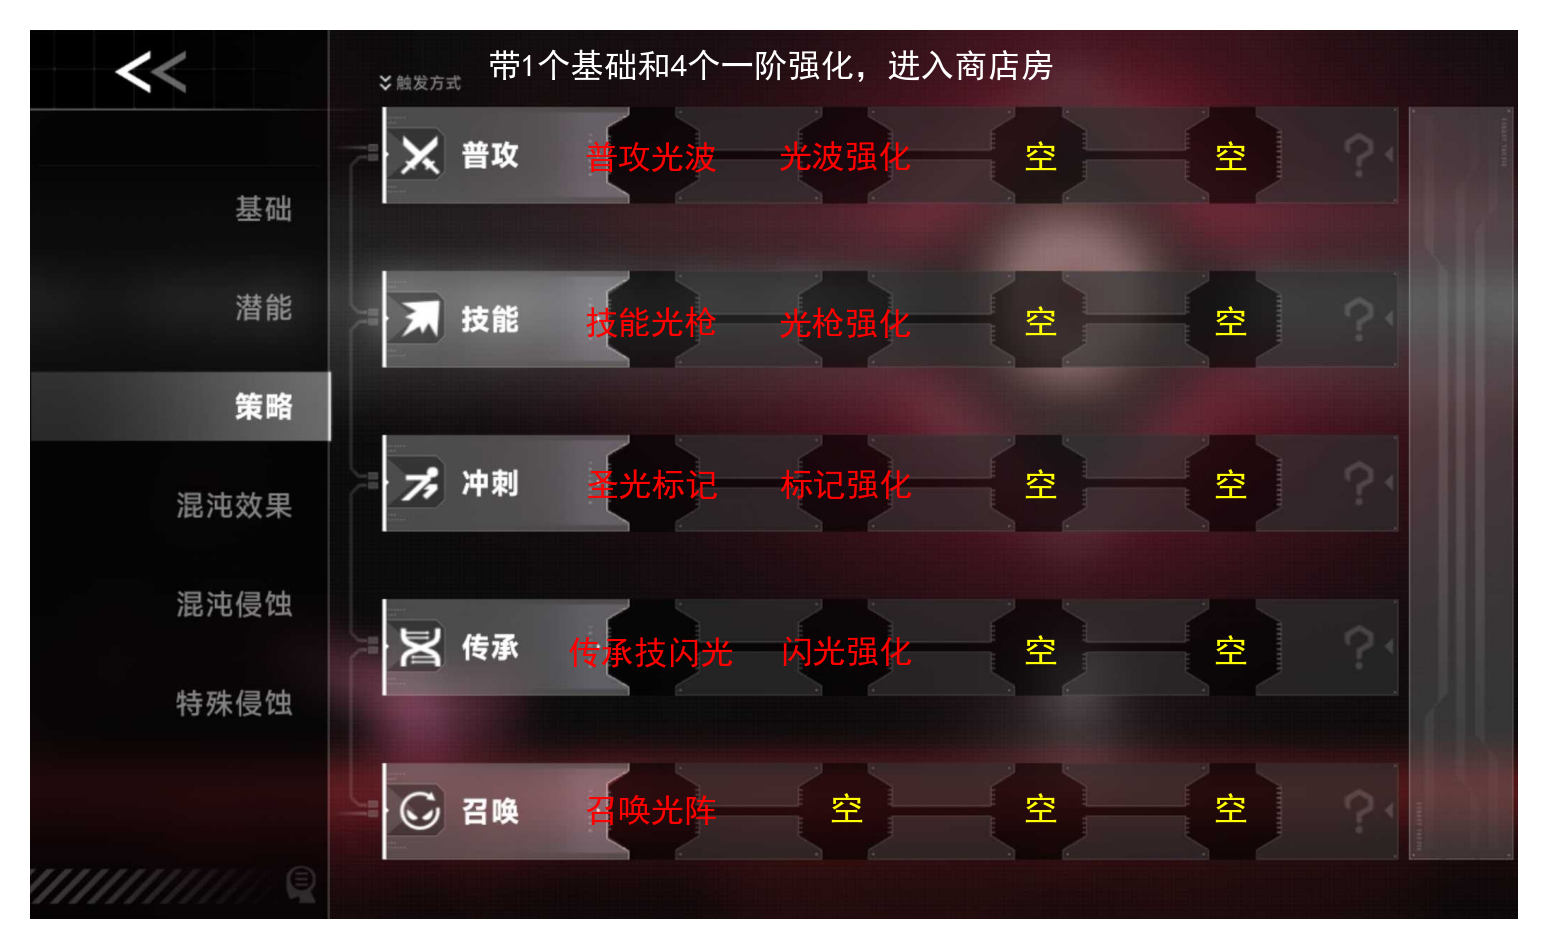

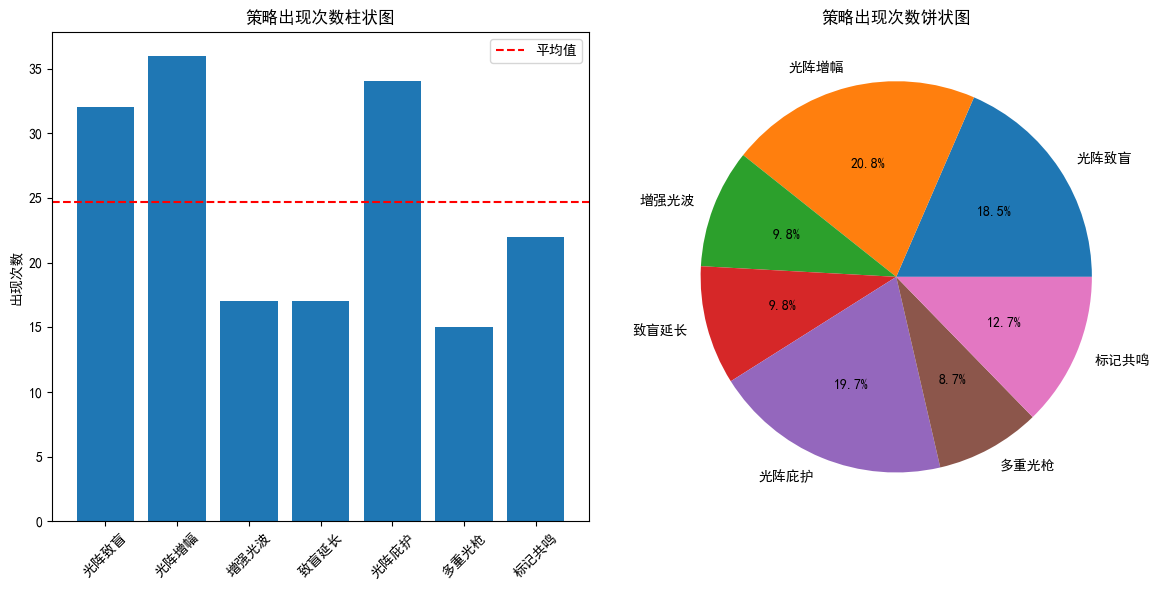

剔除替换策略
卡方统计量: 19.722543352601154, p 值: 0.003102426153314173
数据不太可能来自均匀分布或离散型概率分布。


In [4]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_1个一阶4个二阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带1个基础和4个一阶强化，进入商店房', current_strategies)
strategies = [x for x in strategies if x.level != 0]
utils.plot_element_count([x.name for x in strategies])
print("剔除替换策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 新发现：一阶强化的概率大约是二阶强化的两倍，<font color='red'>出现明显的差距</font>。

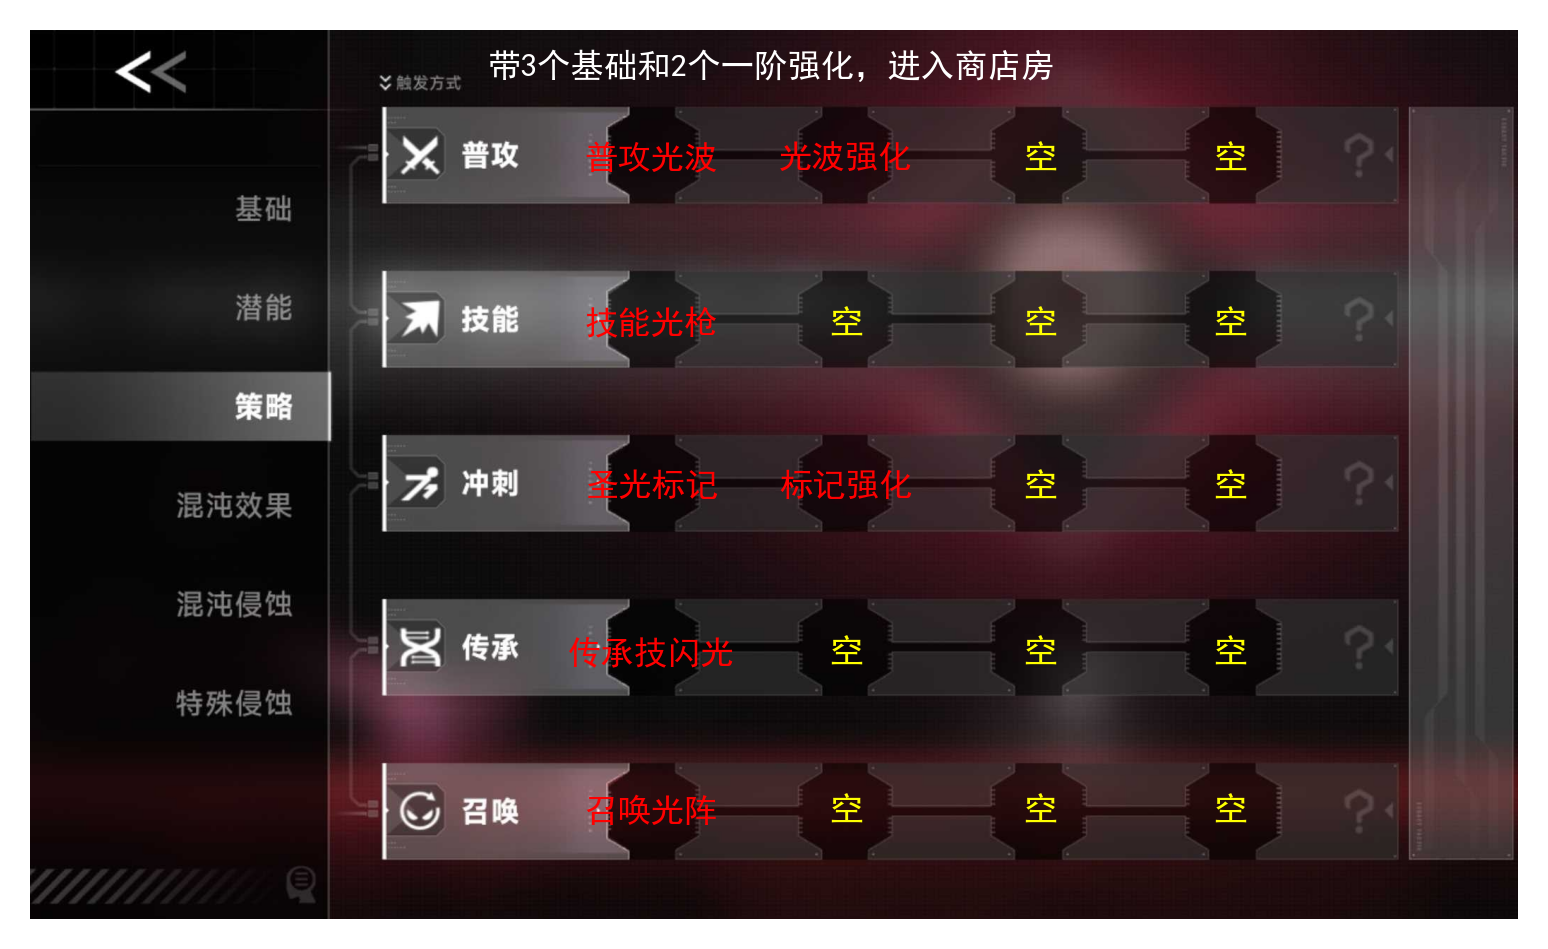

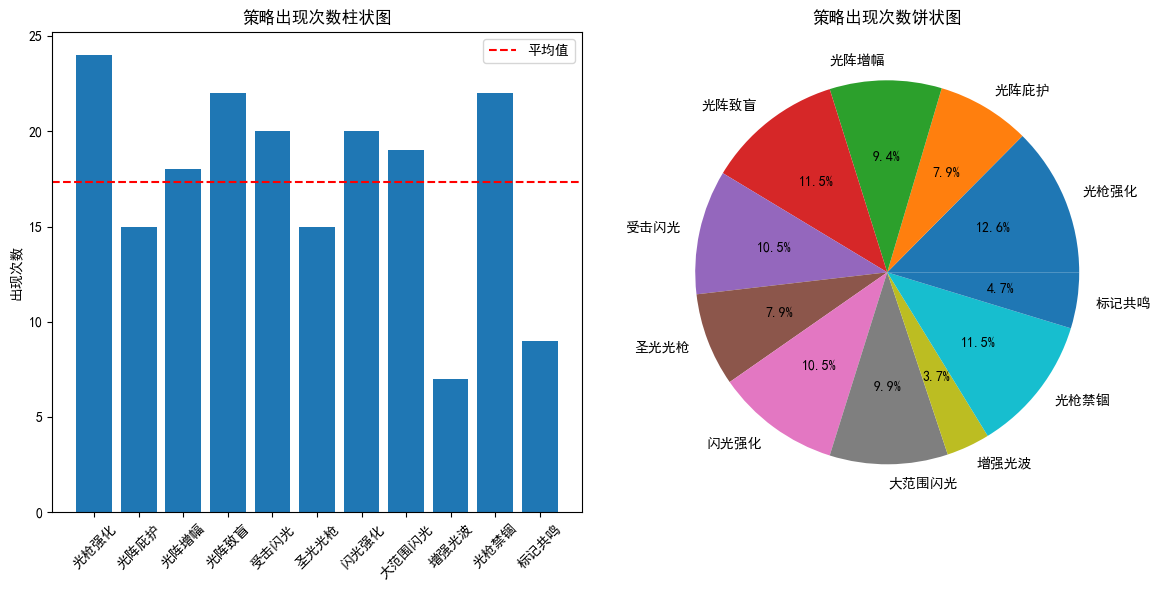

剔除替换策略
卡方统计量: 16.848167539267017, p 值: 0.07779188775772157
数据可能来自均匀分布或离散型概率分布


In [5]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_3个一阶2个二阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带3个基础和2个一阶强化，进入商店房', current_strategies)
strategies = [x for x in strategies if x.level != 0]
utils.plot_element_count([x.name for x in strategies])
print("剔除替换策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图可以明显看出 一阶强化 的概率是 \[增强光波\] 和 \[标记共鸣\] 的 <font color='red'>两倍</red>。

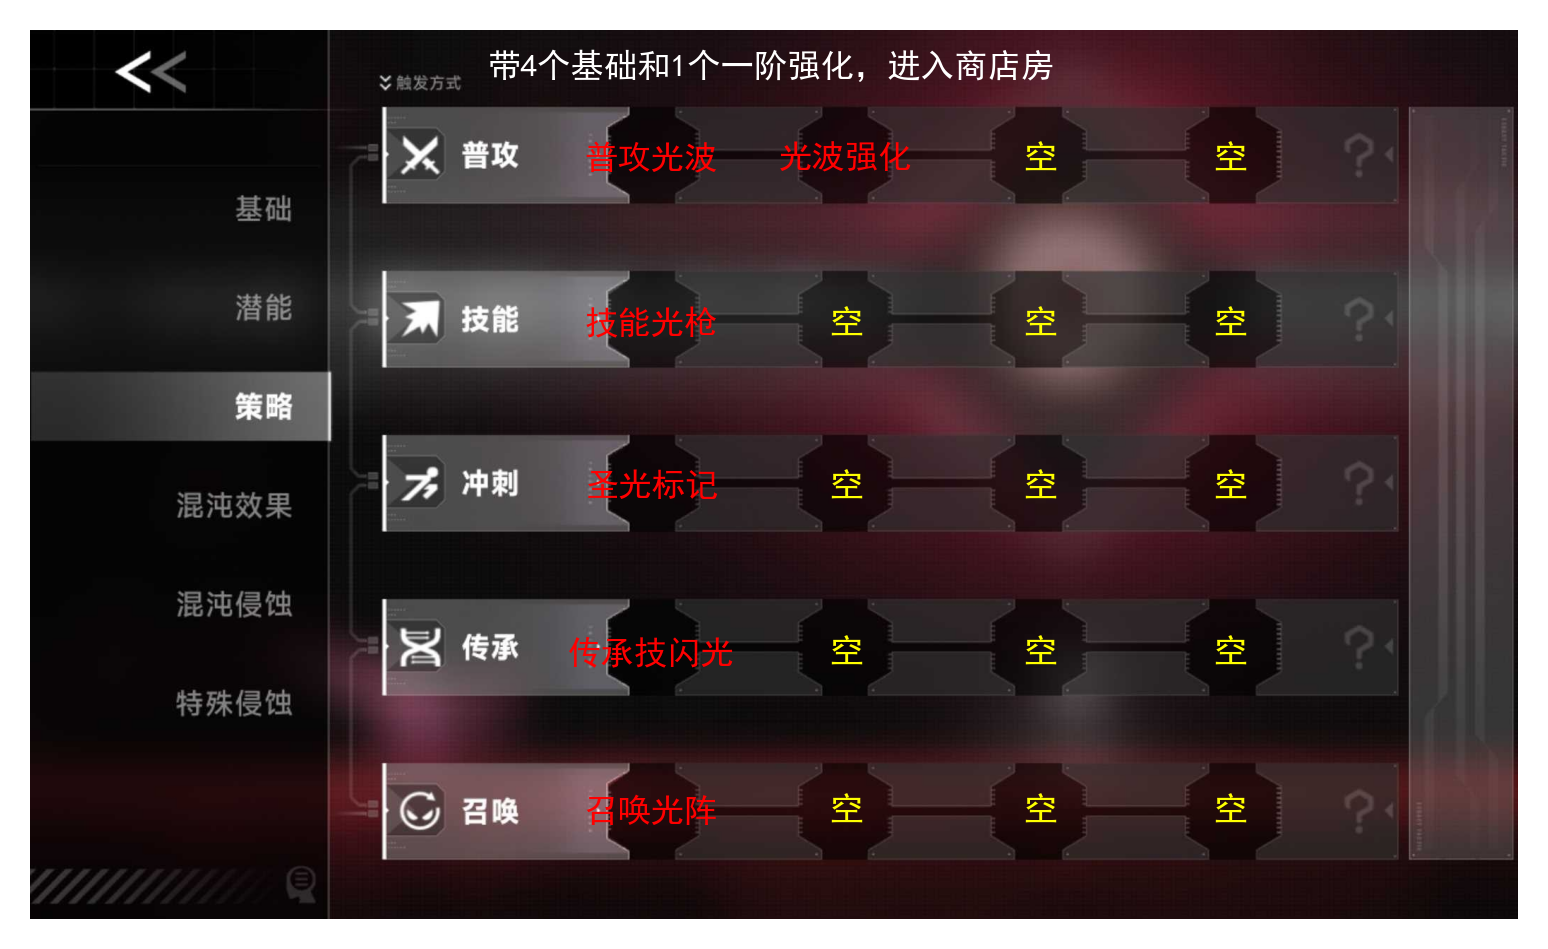

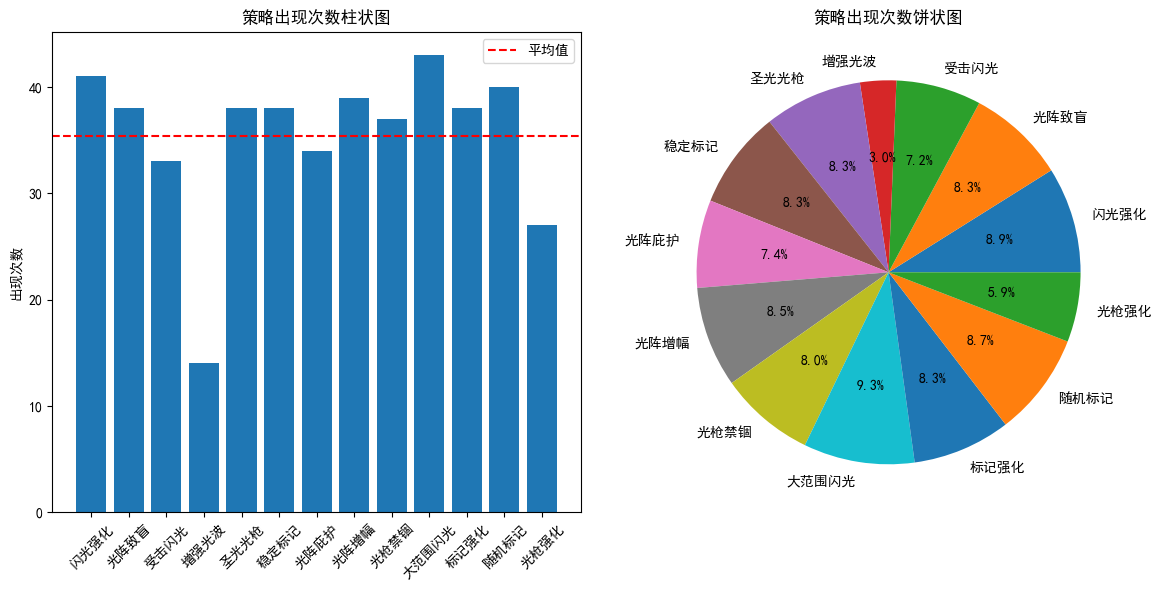

剔除替换策略
卡方统计量: 19.47391304347826, p 值: 0.07771544065568986
数据可能来自均匀分布或离散型概率分布


In [6]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_4个一阶1个二阶.txt")
strategies = list(chain(*strategies))
utils.draw_status('带4个基础和1个一阶强化，进入商店房', current_strategies)
strategies = [x for x in strategies if x.level != 0]
utils.plot_element_count([x.name for x in strategies])
print("剔除替换策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图可以明显看出 一阶强化 的概率是 \[增强光波\] 的 <font color='red'>两倍</red>。

# 修正猜想：一阶强化的概率是二阶强化的两倍。

# 扩展场景：二阶强化和红策略之间概率是否相等。

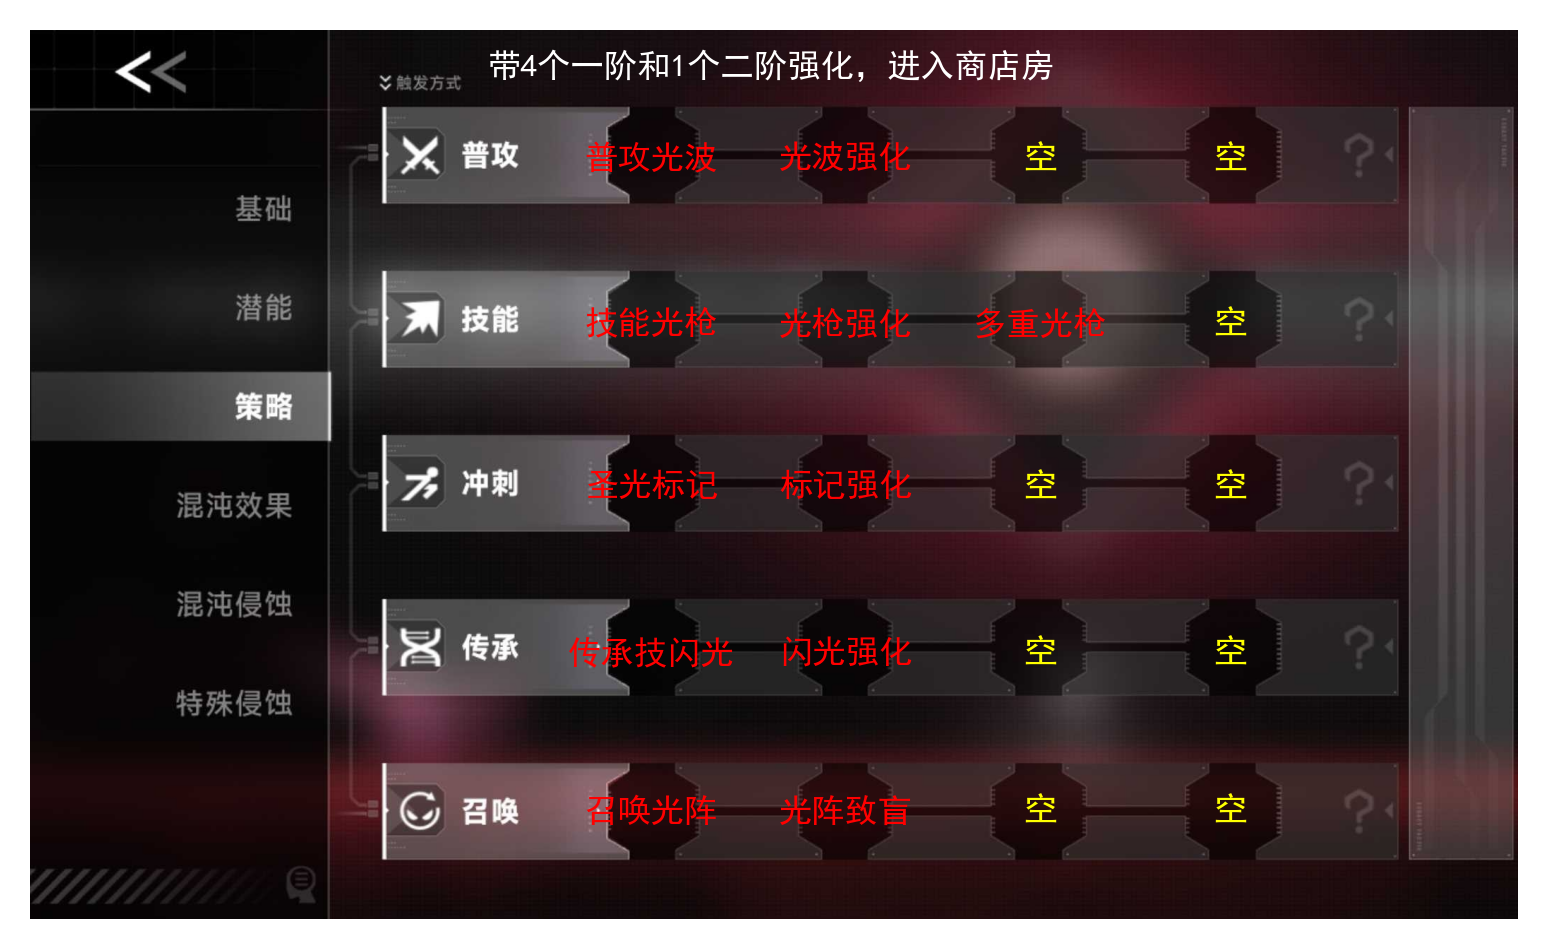

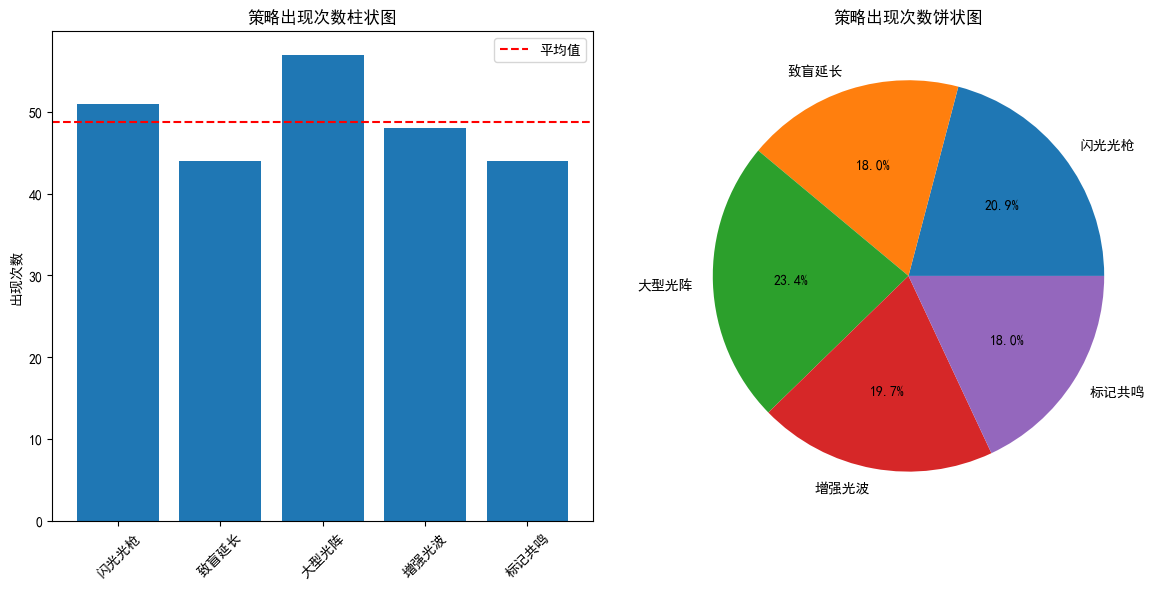

剔除升级策略
卡方统计量: 2.434426229508197, p 值: 0.6564150045338075
数据可能来自均匀分布或离散型概率分布


In [7]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_4个二阶强化1个红.txt")
strategies = list(chain(*strategies))
utils.draw_status('带4个一阶和1个二阶强化，进入商店房', current_strategies)
strategies = [x for x in strategies if x.level > 1]
utils.plot_element_count([x.name for x in strategies])
print("剔除升级策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图得出结论：二阶强化和红策略的概率基本一致

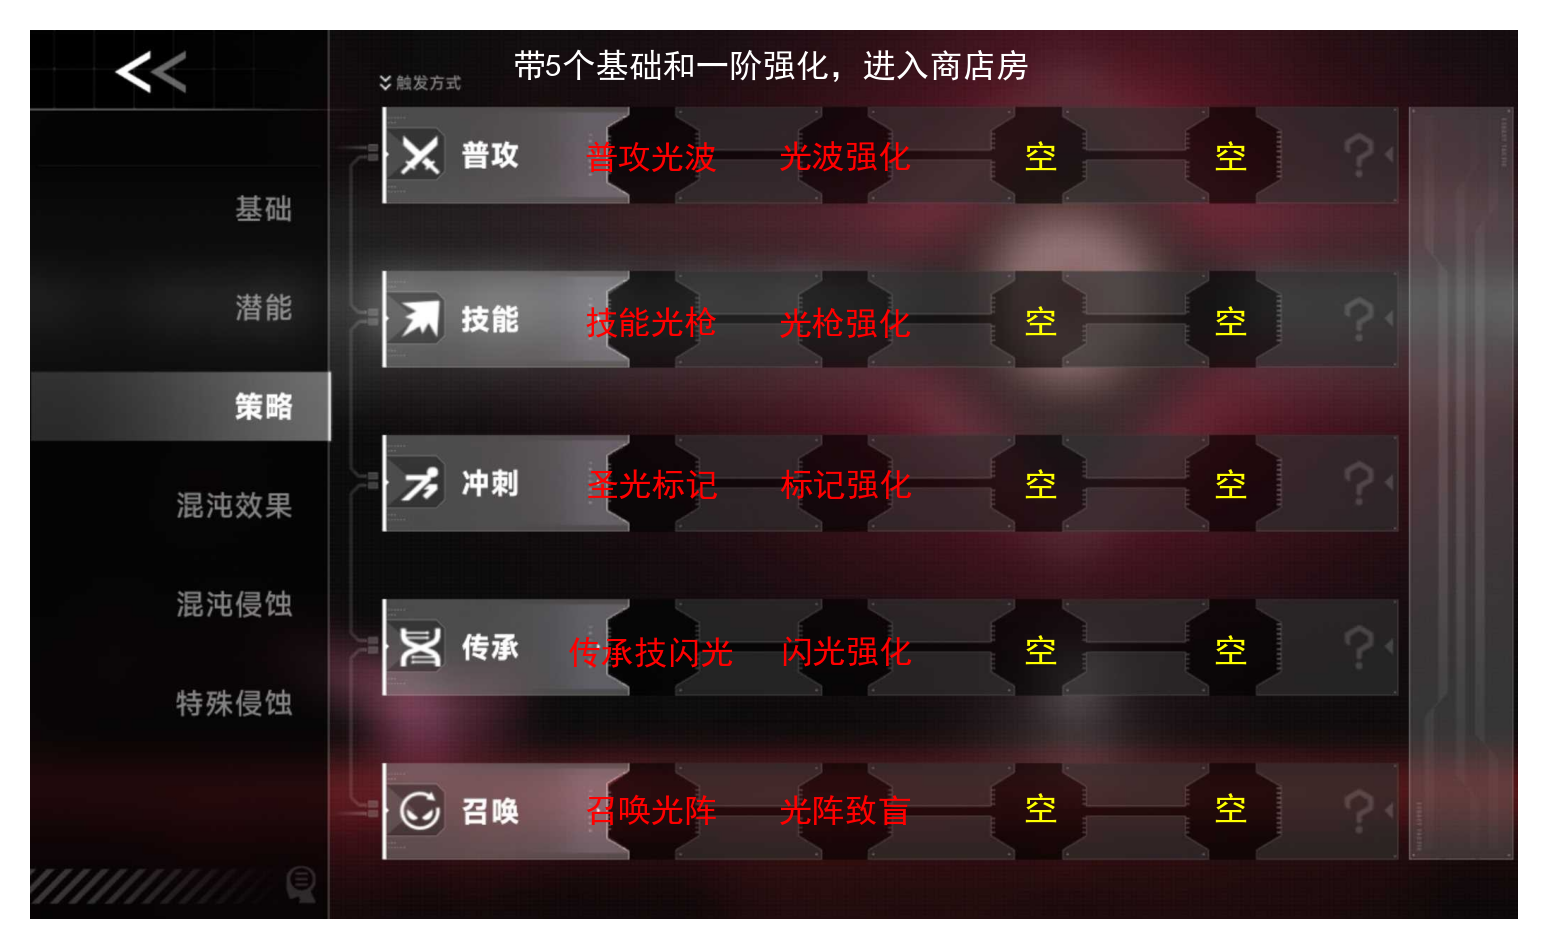

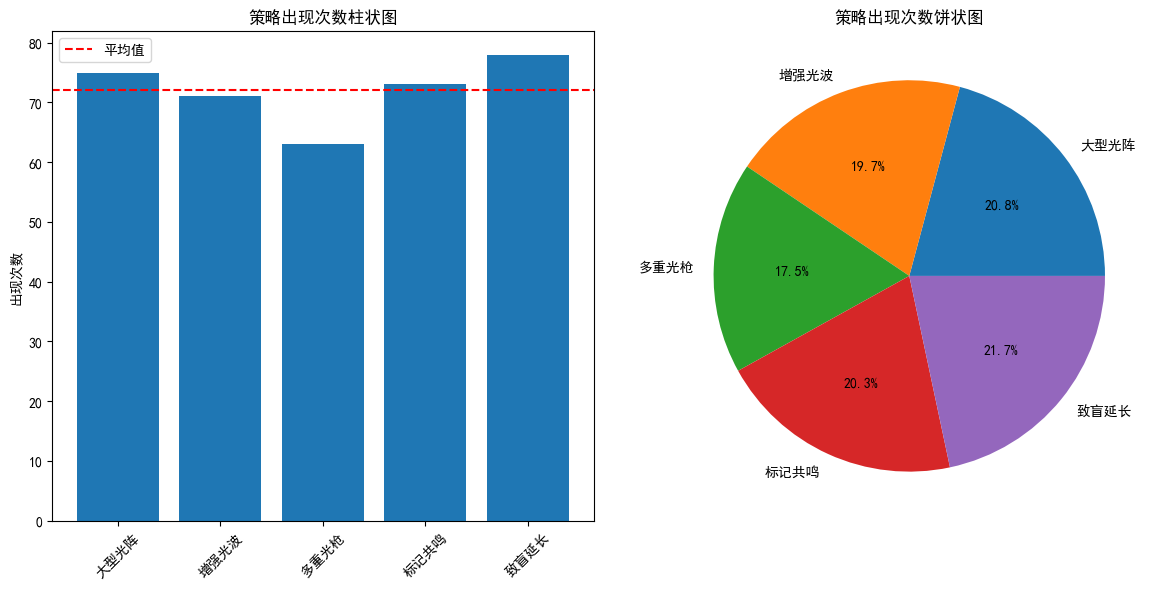

剔除升级策略
卡方统计量: 1.7777777777777777, p 值: 0.7765454376246874
数据可能来自均匀分布或离散型概率分布


In [8]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_5个二阶强化.txt")
strategies = list(chain(*strategies))
utils.draw_status('带5个基础和一阶强化，进入商店房', current_strategies)
strategies = [x for x in strategies if x.level > 1]
utils.plot_element_count([x.name for x in strategies])
print("剔除升级策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图得出结论：二阶强化之间的概率基本一致


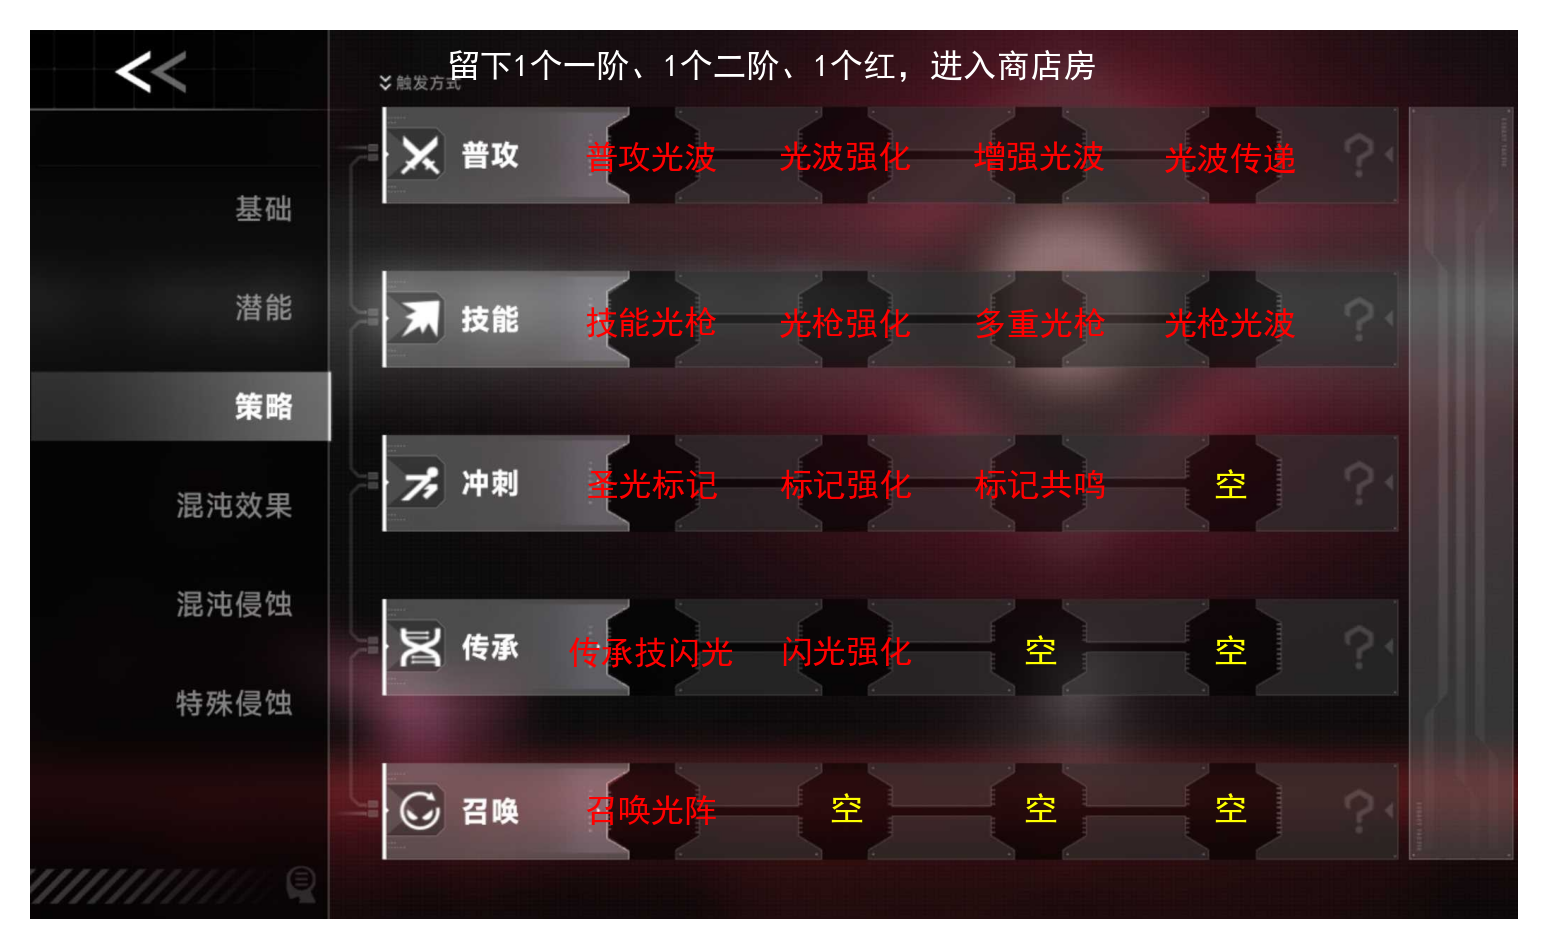

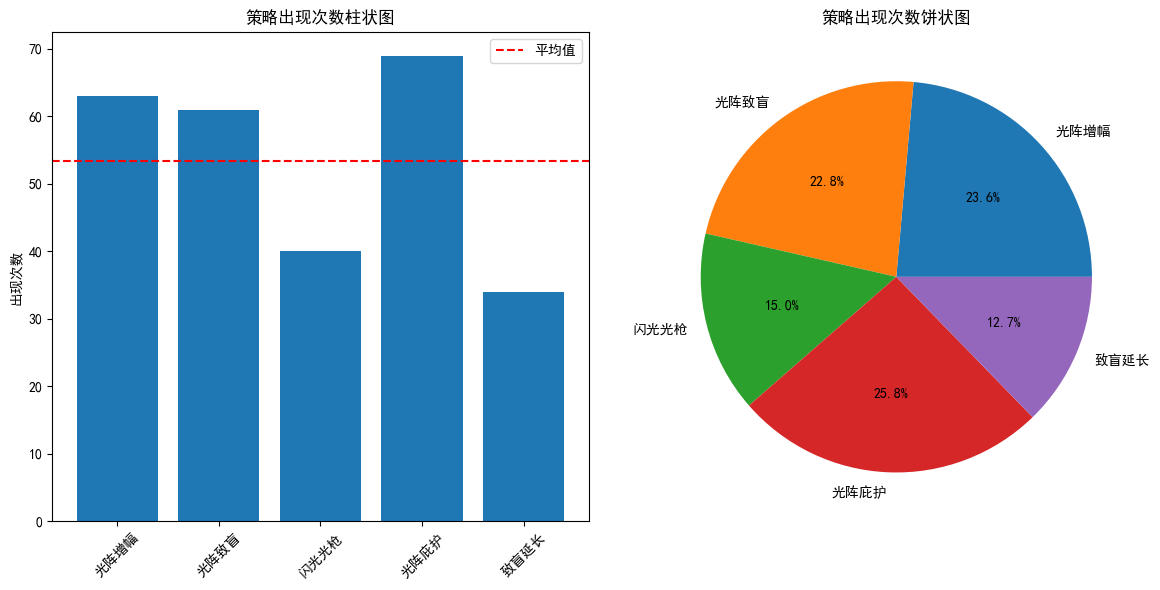

剔除升级策略
卡方统计量: 17.775280898876403, p 值: 0.0013653357475382798
数据不太可能来自均匀分布或离散型概率分布。


In [9]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_1个一阶1个二阶1个红.txt")
utils.draw_status('留下1个一阶、1个二阶、1个红，进入商店房', current_strategies)
strategies = list(chain(*strategies))
current_strategies = list(chain(*current_strategies))
strategies = [x for x in strategies if x.name not in current_strategies]
utils.plot_element_count([x.name for x in strategies])
print("剔除升级策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图可以明显看出 \[致盲延长\] 和 \[闪光光枪\] 的概率<font color='red'>大约是一阶强化的1/2</red>。#

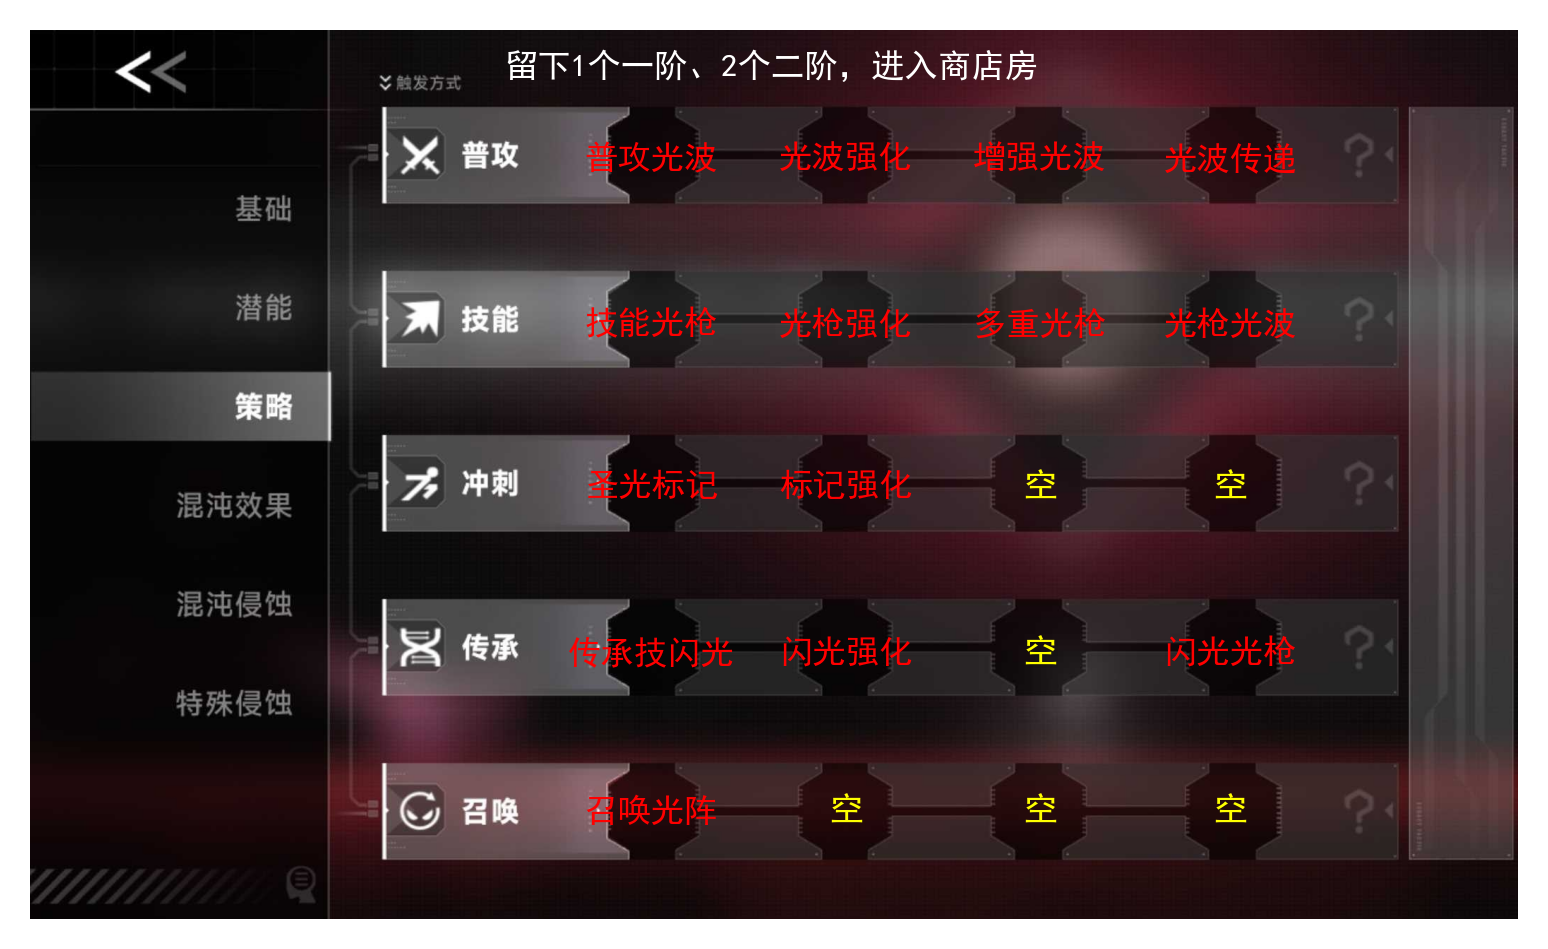

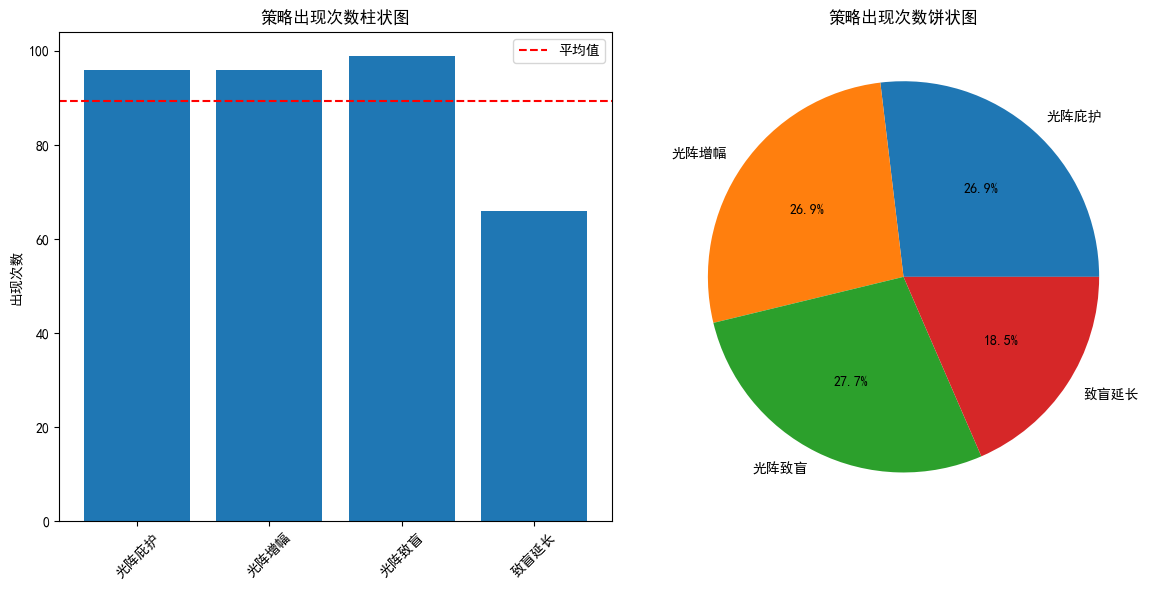

剔除升级策略
卡方统计量: 8.142857142857142, p 值: 0.04314972425390147
数据不太可能来自均匀分布或离散型概率分布。


In [12]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_1个一阶2个二阶.txt")
utils.draw_status('留下1个一阶、2个二阶，进入商店房', current_strategies)
strategies = list(chain(*strategies))
current_strategies = list(chain(*current_strategies))
strategies = [x for x in strategies if x.name not in current_strategies]
utils.plot_element_count([x.name for x in strategies])
print("剔除升级策略")
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图可以明显看出 \[致盲延长\] 的概率<font color='red'>大约是一阶强化的2/3</red>。

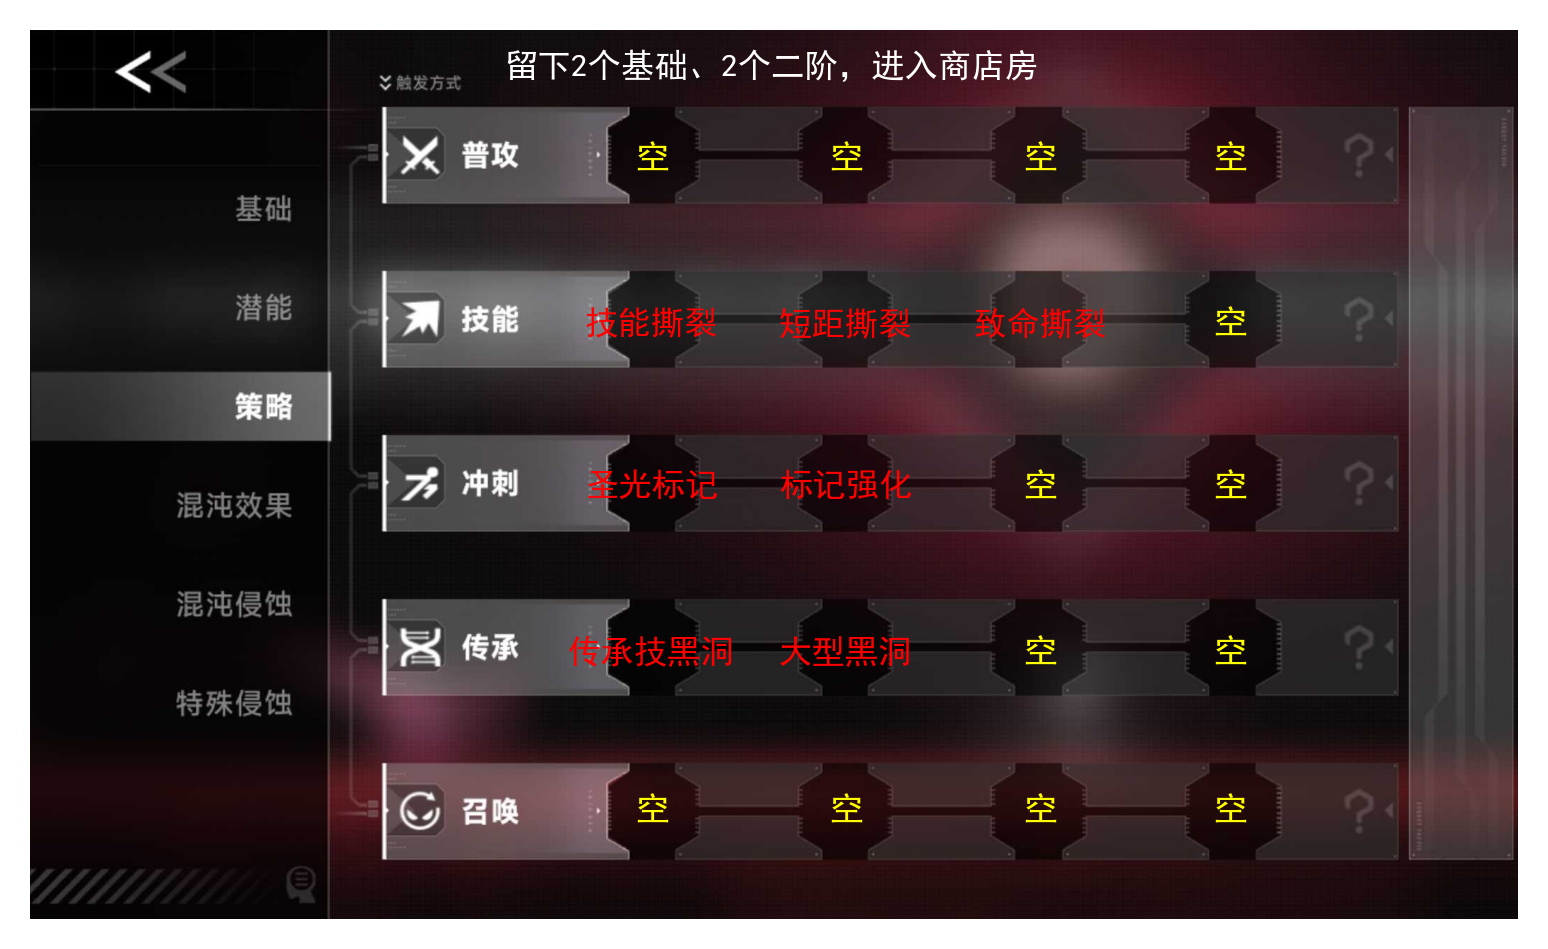

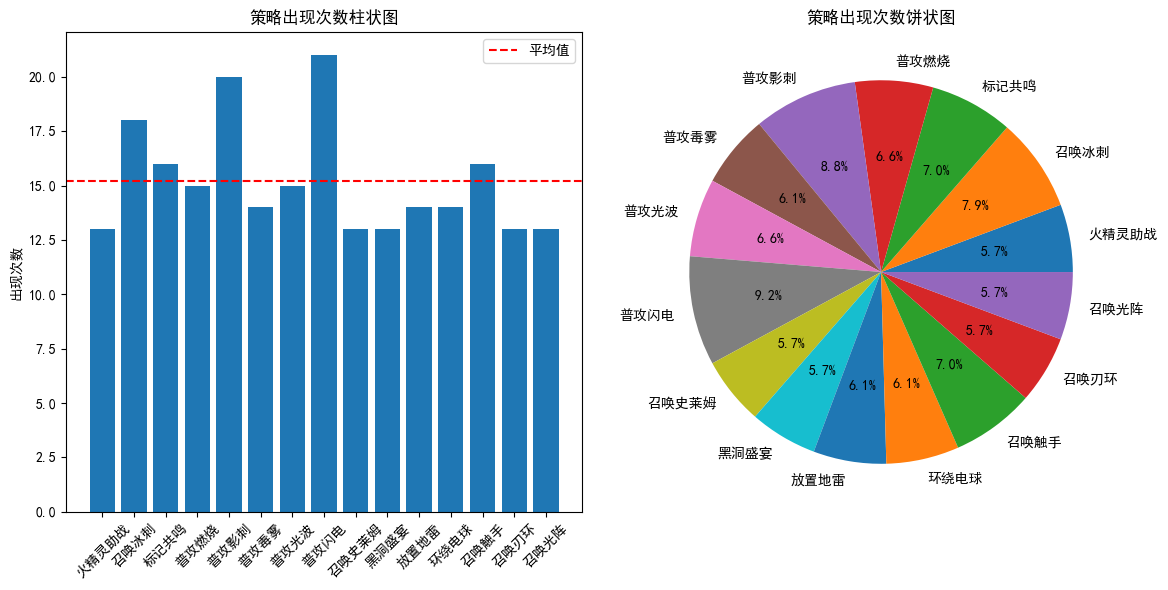

卡方统计量: 6.210526315789474, p 值: 0.9609028134600462
数据可能来自均匀分布或离散型概率分布


In [11]:
current_strategies, strategies = utils.parse_file("data/商店房/商店_2个基础2个二阶.txt")
utils.draw_status('留下2个基础、2个二阶，进入商店房', current_strategies)
strategies = list(chain(*strategies))
utils.plot_element_count([x.name for x in strategies])
chi2, p = utils.test_uniform_distribution(list(Counter(strategies).values()))

# 上图得出结论：基础策略和二阶强化的概率一致。

# 最终结论

## 苍翼第三定律：黑店定律

> 商店内的概率分布不均匀，显然它是个黑店，因此得名 黑店定律

商店房内，策略池内的所有策略根据其类别拥有权重，基础策略、一阶强化、二阶强化、红策略之间的权重大约是：`1:2:1:1`，即一阶强化的权重大约是其他的2倍。

替换策略和策略升级的样本较少且无规律，剔除。